<a href="https://colab.research.google.com/github/hoangnguyen3101/Application-algorithms/blob/main/Lab_Quy_hoach_dong_Dynamic_Programming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB: Quy hoạch động — Dynamic Programming

**Học phần:** Thuật toán ứng dụng  
**Chủ đề:** Quy hoạch động  
**Mức độ:** Cơ bản đến trung bình  
**Ngôn ngữ thực hành:** Python  

---

## Thông tin sinh viên

- Họ và tên: NGUYỄN VĂN HOÀNG
- Mã sinh viên: 23010101
- Lớp: N01
- Ngày thực hiện: 0506

---

## Mục tiêu bài lab

Sau khi hoàn thành bài lab này, sinh viên có thể:

1. Nhận biết bài toán có **tính tối ưu con** và **bài toán con chồng lấp**.
2. Thiết kế trạng thái, điều kiện cơ sở và công thức truy hồi.
3. Phân biệt hai cách cài đặt quy hoạch động: **memoization** và **tabulation**.
4. Cài đặt các bài toán kinh điển: Fibonacci, đổi tiền, ba lô 0-1 và LCS.
5. Truy vết nghiệm từ bảng quy hoạch động.
6. Phân tích độ phức tạp thời gian và bộ nhớ của thuật toán quy hoạch động.
7. Trực quan hóa bảng DP để hiểu quá trình tính toán.

## 1. Quy hoạch động là gì?

**Quy hoạch động** là kỹ thuật giải bài toán bằng cách chia bài toán lớn thành các bài toán con, lưu kết quả của các bài toán con, rồi tái sử dụng để tránh tính lặp lại.

Trực giác:

> Nếu cùng một câu hỏi nhỏ xuất hiện nhiều lần, ta chỉ trả lời một lần và ghi lại kết quả.

Hai điều kiện thường gặp để áp dụng quy hoạch động:

1. **Tính tối ưu con**.
2. **Bài toán con chồng lấp**.

### Tính tối ưu con

Một bài toán có tính tối ưu con nếu nghiệm tối ưu của bài toán lớn có thể được xây dựng từ nghiệm tối ưu của các bài toán con.

Ví dụ: nếu đường đi ngắn nhất từ $$s$$ đến $$t$$ đi qua $$v$$, thì đoạn từ $$s$$ đến $$v$$ cũng phải là đường đi ngắn nhất từ $$s$$ đến $$v$$.

### Bài toán con chồng lấp

Các bài toán con chồng lấp khi cùng một bài toán con được gọi hoặc cần dùng nhiều lần.

Ví dụ Fibonacci:

$$
F(6) = F(5) + F(4)
$$

$$
F(5) = F(4) + F(3)
$$

Giá trị $$F(4)$$ được cần nhiều lần. Đây là dấu hiệu nên nghĩ đến quy hoạch động.

In [31]:
import time
from typing import List, Dict

import pandas as pd
import matplotlib.pyplot as plt

def fib_recursive(n: int, counter: Dict[int, int]) -> int:
    """Đệ quy trực tiếp, có đếm số lần gọi từng F(i)."""
    counter[n] = counter.get(n, 0) + 1
    if n <= 1:
        return n
    return fib_recursive(n - 1, counter) + fib_recursive(n - 2, counter)


def fib_memo(n: int) -> int:
    """Fibonacci bằng memoization."""
    memo = {0: 0, 1: 1}

    def solve(i: int) -> int:
        if i in memo:
            return memo[i]
        memo[i] = solve(i - 1) + solve(i - 2)
        return memo[i]

    return solve(n)


def fib_tabulation(n: int) -> int:
    """Fibonacci bằng tabulation."""
    if n <= 1:
        return n
    dp = [0] * (n + 1)
    dp[0], dp[1] = 0, 1
    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]
    return dp[n]


def fib_space_optimized(n: int) -> int:
    """Fibonacci tối ưu bộ nhớ."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

def greedy_coin_change(coins: List[int], amount: int) -> List[int]:
    """Đổi tiền bằng chiến lược tham lam."""
    result = []
    remaining = amount
    for coin in sorted(coins, reverse=True):
        while remaining >= coin:
            result.append(coin)
            remaining -= coin
    return result if remaining == 0 else []


def min_coins_dp(coins: List[int], amount: int):
    """Trả về dp và parent để truy vết nghiệm đổi tiền."""
    INF = 10**9
    dp = [INF] * (amount + 1)
    parent = [-1] * (amount + 1)
    dp[0] = 0

    for x in range(1, amount + 1):
        for d in coins:
            if d <= x and dp[x - d] + 1 < dp[x]:
                dp[x] = dp[x - d] + 1
                parent[x] = d
    return dp, parent


def reconstruct_coins(parent: List[int], amount: int) -> List[int]:
    result = []
    x = amount
    while x > 0:
        d = parent[x]
        if d == -1:
            return []
        result.append(d)
        x -= d
    return result


def knapsack_01_dp(weights: List[int], values: List[int], capacity: int):
    """Ba lô 0-1 dùng bảng DP hai chiều."""
    n = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]
    take = [[False] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        w = weights[i - 1]
        v = values[i - 1]
        for c in range(capacity + 1):
            dp[i][c] = dp[i - 1][c]
            if w <= c:
                candidate = dp[i - 1][c - w] + v
                if candidate > dp[i][c]:
                    dp[i][c] = candidate
                    take[i][c] = True
    return dp, take


def reconstruct_knapsack_items(weights: List[int], values: List[int], capacity: int, take: List[List[bool]]):
    selected = []
    i = len(weights)
    c = capacity
    while i > 0:
        if take[i][c]:
            selected.append(i)
            c -= weights[i - 1]
        i -= 1
    selected.reverse()
    return selected


def knapsack_01_optimized(weights: List[int], values: List[int], capacity: int):
    """Ba lô 0-1 tối ưu bộ nhớ O(W)."""
    dp = [0] * (capacity + 1)
    for w, v in zip(weights, values):
        for c in range(capacity, w - 1, -1):
            dp[c] = max(dp[c], dp[c - w] + v)
    return dp


def lcs_dp(X: str, Y: str):
    """Tính bảng DP cho LCS."""
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp


def reconstruct_lcs(X: str, Y: str, dp: List[List[int]]) -> str:
    """Truy vết một LCS từ bảng DP."""
    i, j = len(X), len(Y)
    result = []

    while i > 0 and j > 0:
        if X[i - 1] == Y[j - 1]:
            result.append(X[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] >= dp[i][j - 1]:
            i -= 1
        else:
            j -= 1

    result.reverse()
    return "".join(result)


## 2. Quy trình thiết kế quy hoạch động

Khi giải một bài toán bằng quy hoạch động, có thể đi theo các bước sau:

1. **Xác định trạng thái:** $$dp[\ldots]$$ đại diện cho điều gì?
2. **Xác định đáp án:** đáp án nằm ở ô nào của bảng?
3. **Viết công thức truy hồi:** trạng thái hiện tại phụ thuộc trạng thái nào?
4. **Đặt điều kiện cơ sở:** giá trị ban đầu khi bài toán rất nhỏ.
5. **Chọn thứ tự tính:** bảo đảm trạng thái phụ thuộc đã có trước.
6. **Phân tích độ phức tạp:** đếm số trạng thái và chi phí mỗi trạng thái.

Mẫu tư duy quan trọng:

$$
\text{Độ phức tạp}
=
\text{số trạng thái}
\times
\text{số lựa chọn cho mỗi trạng thái}.
$$

## 3. Ví dụ 1: Fibonacci

Dãy Fibonacci được định nghĩa bởi:

$$
F(n) = F(n-1) + F(n-2)
$$

với:

$$
F(0)=0,\qquad F(1)=1.
$$

Ta sẽ so sánh bốn cách cài đặt:

1. Đệ quy trực tiếp.
2. Memoization.
3. Tabulation.
4. Tối ưu bộ nhớ.

In [10]:
def fib_recursive(n: int, counter: Dict[int, int]) -> int:
    """Đệ quy trực tiếp, có đếm số lần gọi từng F(i)."""
    counter[n] = counter.get(n, 0) + 1
    if n <= 1:
        return n
    return fib_recursive(n - 1, counter) + fib_recursive(n - 2, counter)


def fib_memo(n: int) -> int:
    """Fibonacci bằng memoization."""
    memo = {0: 0, 1: 1}

    def solve(i: int) -> int:
        if i in memo:
            return memo[i]
        memo[i] = solve(i - 1) + solve(i - 2)
        return memo[i]

    return solve(n)


def fib_tabulation(n: int) -> int:
    """Fibonacci bằng tabulation."""
    if n <= 1:
        return n
    dp = [0] * (n + 1)
    dp[0], dp[1] = 0, 1
    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]
    return dp[n]


def fib_space_optimized(n: int) -> int:
    """Fibonacci tối ưu bộ nhớ."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b


n = 10
counter = {}
print("Fibonacci recursive:", fib_recursive(n, counter))
print("Fibonacci memoization:", fib_memo(n))
print("Fibonacci tabulation:", fib_tabulation(n))
print("Fibonacci space optimized:", fib_space_optimized(n))

pd.DataFrame(sorted(counter.items()), columns=["i", "Số lần gọi F(i)"])

Fibonacci recursive: 55
Fibonacci memoization: 55
Fibonacci tabulation: 55
Fibonacci space optimized: 55


,i,Số lần gọi F(i)
0,0,34
1,1,55
2,2,34
3,3,21
4,4,13
5,5,8
6,6,5
7,7,3
8,8,2
9,9,1


### 3.1. Quan sát số lần tính lặp lại

Trong đệ quy trực tiếp, cùng một giá trị $$F(i)$$ có thể bị tính lại nhiều lần.

Cell dưới đây vẽ số lần gọi từng bài toán con khi tính $$F(n)$$ bằng đệ quy trực tiếp.

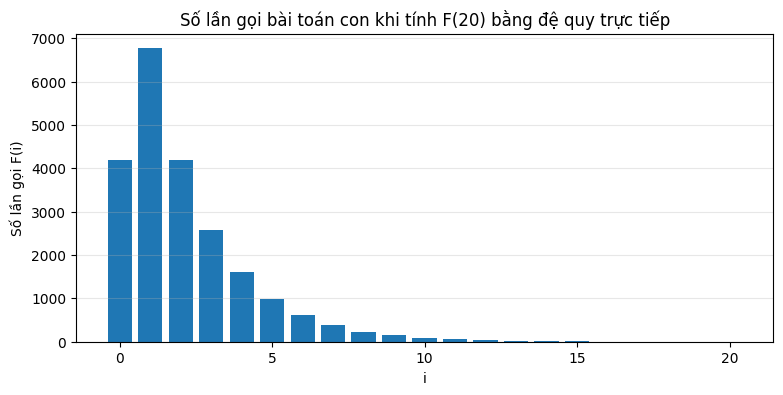

,i,calls
0,0,4181
1,1,6765
2,2,4181
3,3,2584
4,4,1597
5,5,987
6,6,610
7,7,377
8,8,233
9,9,144


In [11]:
n = 20
counter = {}
_ = fib_recursive(n, counter)

df_calls = pd.DataFrame(sorted(counter.items()), columns=["i", "calls"])

plt.figure(figsize=(9, 4))
plt.bar(df_calls["i"], df_calls["calls"])
plt.xlabel("i")
plt.ylabel("Số lần gọi F(i)")
plt.title(f"Số lần gọi bài toán con khi tính F({n}) bằng đệ quy trực tiếp")
plt.grid(axis="y", alpha=0.3)
plt.show()

df_calls

### 3.2. So sánh thời gian chạy

Đệ quy trực tiếp có thời gian tăng rất nhanh. Memoization và tabulation giúp mỗi trạng thái $$F(i)$$ chỉ được tính một lần.

In [12]:
def measure_time(func, n: int, repeat: int = 1):
    start = time.perf_counter()
    result = None
    for _ in range(repeat):
        result = func(n)
    end = time.perf_counter()
    return result, (end - start) / repeat


test_ns = list(range(5, 31, 5))
rows = []

for x in test_ns:
    rec_counter = {}
    t0 = time.perf_counter()
    _ = fib_recursive(x, rec_counter)
    t1 = time.perf_counter()

    _, memo_time = measure_time(fib_memo, x)
    tab_value, tab_time = measure_time(fib_tabulation, x)
    _, opt_time = measure_time(fib_space_optimized, x)

    rows.append({
        "n": x,
        "recursive_time": t1 - t0,
        "memo_time": memo_time,
        "tabulation_time": tab_time,
        "space_opt_time": opt_time,
        "value": tab_value,
    })

df_fib_time = pd.DataFrame(rows)
df_fib_time

,n,recursive_time,memo_time,tabulation_time,space_opt_time,value
0,5,0.000009,0.000008,0.000006,0.000002,5
1,10,0.000044,0.000007,0.000002,0.000001,55
2,15,0.000481,0.000013,0.000005,0.000002,610
3,20,0.009852,0.000027,0.000010,0.000003,6765
4,25,0.192243,0.000033,0.000012,0.000003,75025
5,30,1.230965,0.000034,0.000011,0.000004,832040


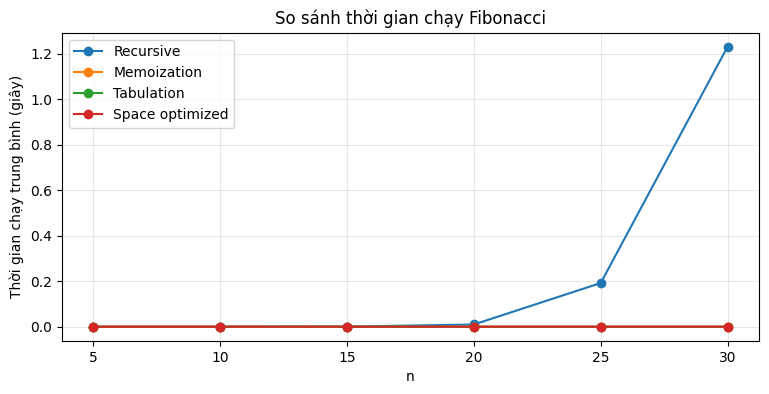

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(df_fib_time["n"], df_fib_time["recursive_time"], marker="o", label="Recursive")
plt.plot(df_fib_time["n"], df_fib_time["memo_time"], marker="o", label="Memoization")
plt.plot(df_fib_time["n"], df_fib_time["tabulation_time"], marker="o", label="Tabulation")
plt.plot(df_fib_time["n"], df_fib_time["space_opt_time"], marker="o", label="Space optimized")
plt.xlabel("n")
plt.ylabel("Thời gian chạy trung bình (giây)")
plt.title("So sánh thời gian chạy Fibonacci")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Memoization và Tabulation

Hai cách cài đặt quy hoạch động thường gặp:

### Memoization

Memoization là cách tiếp cận **từ trên xuống**.

Ta viết đệ quy tự nhiên, nhưng trước khi tính một trạng thái, kiểm tra xem trạng thái đó đã có trong bảng nhớ chưa.

Mẫu tổng quát:

$$
solve(x)=
\begin{cases}
\text{giá trị cơ sở}, & x \text{ đủ nhỏ},\\
memo[x], & x \text{ đã được tính},\\
\text{tính từ các } solve(y), & \text{ngược lại}.
\end{cases}
$$

### Tabulation

Tabulation là cách tiếp cận **từ dưới lên**.

Ta tính các trạng thái nhỏ trước, rồi dùng chúng để tính các trạng thái lớn hơn theo thứ tự xác định.

Với Fibonacci:

$$
dp[0]=0,\qquad dp[1]=1
$$

$$
dp[i]=dp[i-1]+dp[i-2],\quad 2 \le i \le n.
$$

## 5. Ví dụ 2: Bài toán đổi tiền

### Phát biểu bài toán

Cho các mệnh giá:

$$
D=\{d_1,d_2,\ldots,d_k\}
$$

và số tiền $$n$$.

Hãy tìm số đồng xu ít nhất có tổng bằng $$n$$.

### Vì sao tham lam có thể sai?

Với:

$$
D=\{1,3,4\},\qquad n=6
$$

Nếu tham lam chọn đồng lớn nhất trước:

$$
6 = 4 + 1 + 1
$$

cần 3 đồng.

Nhưng nghiệm tối ưu là:

$$
6 = 3 + 3
$$

chỉ cần 2 đồng.

In [14]:
def greedy_coin_change(coins: List[int], amount: int) -> List[int]:
    """Đổi tiền bằng chiến lược tham lam."""
    result = []
    remaining = amount
    for coin in sorted(coins, reverse=True):
        while remaining >= coin:
            result.append(coin)
            remaining -= coin
    return result if remaining == 0 else []


coins = [1, 3, 4]
amount = 6
greedy_solution = greedy_coin_change(coins, amount)

print("Mệnh giá:", coins)
print("Số tiền:", amount)
print("Tham lam chọn:", greedy_solution)
print("Số đồng:", len(greedy_solution))

Mệnh giá: [1, 3, 4]
Số tiền: 6
Tham lam chọn: [4, 1, 1]
Số đồng: 3


### 5.1. Trạng thái và công thức truy hồi

Định nghĩa trạng thái:

$$
dp[x] = \text{số đồng xu ít nhất để đổi được số tiền } x.
$$

Điều kiện cơ sở:

$$
dp[0] = 0.
$$

Truy hồi:

$$
dp[x]
=
1 + \min_{\substack{d \in D \\ d \le x}} dp[x-d].
$$

Ý nghĩa: thử tất cả khả năng chọn đồng cuối cùng có mệnh giá $$d$$, rồi lấy phương án tốt nhất.

In [15]:
def min_coins_dp(coins: List[int], amount: int):
    """Trả về dp và parent để truy vết nghiệm đổi tiền."""
    INF = 10**9
    dp = [INF] * (amount + 1)
    parent = [-1] * (amount + 1)
    dp[0] = 0

    for x in range(1, amount + 1):
        for d in coins:
            if d <= x and dp[x - d] + 1 < dp[x]:
                dp[x] = dp[x - d] + 1
                parent[x] = d
    return dp, parent


def reconstruct_coins(parent: List[int], amount: int) -> List[int]:
    result = []
    x = amount
    while x > 0:
        d = parent[x]
        if d == -1:
            return []
        result.append(d)
        x -= d
    return result


coins = [1, 3, 4]
amount = 6
dp_coin, parent_coin = min_coins_dp(coins, amount)
optimal_coins = reconstruct_coins(parent_coin, amount)

df_coin = pd.DataFrame({"x": list(range(amount + 1)), "dp[x]": dp_coin, "coin cuối": parent_coin})
print("Nghiệm tối ưu:", optimal_coins)
print("Số đồng tối ưu:", dp_coin[amount])
df_coin

Nghiệm tối ưu: [3, 3]
Số đồng tối ưu: 2


,x,dp[x],coin cuối
0,0,0,-1
1,1,1,1
2,2,2,1
3,3,1,3
4,4,1,4
5,5,2,1
6,6,2,3


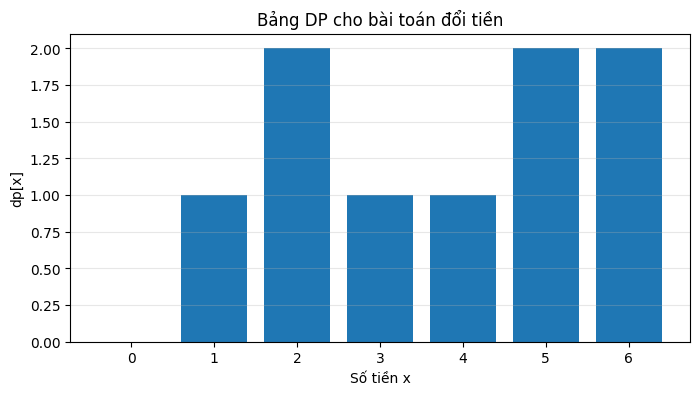

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(df_coin["x"], df_coin["dp[x]"])
plt.xlabel("Số tiền x")
plt.ylabel("dp[x]")
plt.title("Bảng DP cho bài toán đổi tiền")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 6. Ví dụ 3: Bài toán ba lô 0-1

### Phát biểu bài toán

Có $$n$$ đồ vật. Vật $$i$$ có trọng lượng $$w_i$$ và giá trị $$v_i$$. Ba lô có sức chứa $$W$$. Mỗi vật chỉ được chọn hoặc không chọn.

Mục tiêu là tối đa hóa tổng giá trị mà không vượt quá sức chứa.

### Trạng thái

$$
dp[i][c]
=
\text{giá trị lớn nhất khi xét } i \text{ vật đầu tiên và sức chứa } c.
$$

Điều kiện cơ sở:

$$
dp[0][c] = 0
$$

$$
dp[i][0] = 0
$$

Đáp án:

$$
dp[n][W].
$$

### Công thức truy hồi

Khi xét vật $$i$$:

$$
dp[i][c]
=
\begin{cases}
dp[i-1][c], & w_i > c,\\
\max\{dp[i-1][c], dp[i-1][c-w_i] + v_i\}, & w_i \le c.
\end{cases}
$$

In [17]:
def knapsack_01_dp(weights: List[int], values: List[int], capacity: int):
    """Ba lô 0-1 dùng bảng DP hai chiều."""
    n = len(weights)
    dp = [[0] * (capacity + 1) for _ in range(n + 1)]
    take = [[False] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        w = weights[i - 1]
        v = values[i - 1]
        for c in range(capacity + 1):
            dp[i][c] = dp[i - 1][c]
            if w <= c:
                candidate = dp[i - 1][c - w] + v
                if candidate > dp[i][c]:
                    dp[i][c] = candidate
                    take[i][c] = True
    return dp, take


def reconstruct_knapsack_items(weights: List[int], values: List[int], capacity: int, take: List[List[bool]]):
    selected = []
    i = len(weights)
    c = capacity
    while i > 0:
        if take[i][c]:
            selected.append(i)
            c -= weights[i - 1]
        i -= 1
    selected.reverse()
    return selected


weights = [2, 3, 4]
values = [3, 4, 5]
capacity = 5

dp_knap, take_knap = knapsack_01_dp(weights, values, capacity)
selected_items = reconstruct_knapsack_items(weights, values, capacity, take_knap)

print("Trọng lượng:", weights)
print("Giá trị:", values)
print("Sức chứa:", capacity)
print("Giá trị tối ưu:", dp_knap[len(weights)][capacity])
print("Các vật được chọn, đánh số từ 1:", selected_items)

pd.DataFrame(dp_knap)

Trọng lượng: [2, 3, 4]
Giá trị: [3, 4, 5]
Sức chứa: 5
Giá trị tối ưu: 7
Các vật được chọn, đánh số từ 1: [1, 2]


,0,1,2,3,4,5
0,0,0,0,0,0,0
1,0,0,3,3,3,3
2,0,0,3,4,4,7
3,0,0,3,4,5,7


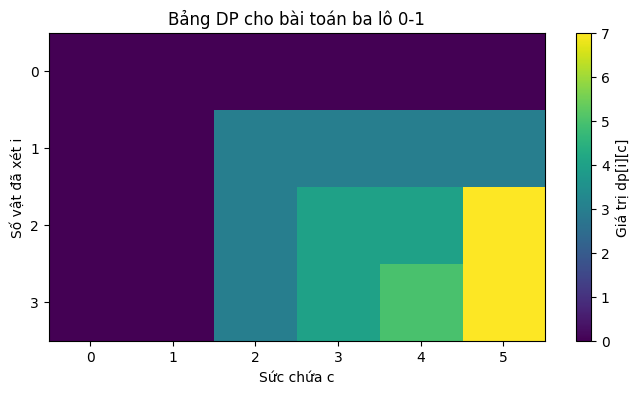

In [18]:
plt.figure(figsize=(8, 4))
plt.imshow(dp_knap, aspect="auto")
plt.colorbar(label="Giá trị dp[i][c]")
plt.xlabel("Sức chứa c")
plt.ylabel("Số vật đã xét i")
plt.title("Bảng DP cho bài toán ba lô 0-1")
plt.xticks(range(capacity + 1))
plt.yticks(range(len(weights) + 1))
plt.show()

### 6.1. Tối ưu bộ nhớ cho ba lô 0-1

Vì $$dp[i][c]$$ chỉ phụ thuộc hàng $$i-1$$, có thể dùng mảng một chiều:

$$
dp[c] = \max(dp[c], dp[c-w_i] + v_i).
$$

Lưu ý: với ba lô 0-1, vòng lặp sức chứa phải đi **giảm dần** để mỗi vật chỉ được dùng một lần.

In [19]:
def knapsack_01_optimized(weights: List[int], values: List[int], capacity: int):
    """Ba lô 0-1 tối ưu bộ nhớ O(W)."""
    dp = [0] * (capacity + 1)
    for w, v in zip(weights, values):
        for c in range(capacity, w - 1, -1):
            dp[c] = max(dp[c], dp[c - w] + v)
    return dp


dp_knap_1d = knapsack_01_optimized(weights, values, capacity)
print("DP 1D:", dp_knap_1d)
print("Giá trị tối ưu:", dp_knap_1d[capacity])

DP 1D: [0, 0, 3, 4, 5, 7]
Giá trị tối ưu: 7


## 7. Ví dụ 4: Dãy con chung dài nhất — LCS

### Phát biểu bài toán

Cho hai xâu:

$$
X=x_1x_2\ldots x_m
$$

và:

$$
Y=y_1y_2\ldots y_n.
$$

Tìm độ dài **dãy con chung dài nhất**, hay Longest Common Subsequence.

Dãy con là dãy giữ nguyên thứ tự ký tự, nhưng không cần liên tiếp.

Ví dụ:

$$
X=\text{ABCBDAB}
$$

$$
Y=\text{BDCABA}
$$

Một LCS là:

$$
\text{BCBA}
$$

có độ dài 4.

### 7.1. Trạng thái và công thức truy hồi

Định nghĩa:

$$
dp[i][j]
=
\text{độ dài LCS của } X[0..i-1] \text{ và } Y[0..j-1].
$$

Điều kiện cơ sở:

$$
dp[0][j]=0
$$

$$
dp[i][0]=0
$$

Nếu ký tự cuối hai tiền tố giống nhau:

$$
X[i-1] = Y[j-1]
$$

thì:

$$
dp[i][j] = dp[i-1][j-1] + 1.
$$

Nếu khác nhau:

$$
dp[i][j] = \max\{dp[i-1][j], dp[i][j-1]\}.
$$

Đáp án là:

$$
dp[m][n].
$$

In [20]:
def lcs_dp(X: str, Y: str):
    """Tính bảng DP cho LCS."""
    m, n = len(X), len(Y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if X[i - 1] == Y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp


def reconstruct_lcs(X: str, Y: str, dp: List[List[int]]) -> str:
    """Truy vết một LCS từ bảng DP."""
    i, j = len(X), len(Y)
    result = []

    while i > 0 and j > 0:
        if X[i - 1] == Y[j - 1]:
            result.append(X[i - 1])
            i -= 1
            j -= 1
        elif dp[i - 1][j] >= dp[i][j - 1]:
            i -= 1
        else:
            j -= 1

    result.reverse()
    return "".join(result)


X = "ABCBDAB"
Y = "BDCABA"

dp_lcs = lcs_dp(X, Y)
lcs_str = reconstruct_lcs(X, Y, dp_lcs)

print("X =", X)
print("Y =", Y)
print("Độ dài LCS:", dp_lcs[len(X)][len(Y)])
print("Một LCS:", lcs_str)

pd.DataFrame(dp_lcs, index=[""] + list(X), columns=[""] + list(Y))

X = ABCBDAB
Y = BDCABA
Độ dài LCS: 4
Một LCS: BCBA


,,B,D,C,A,B,A
,0,0,0,0,0,0,0
A,0,0,0,0,1,1,1
B,0,1,1,1,1,2,2
C,0,1,1,2,2,2,2
B,0,1,1,2,2,3,3
D,0,1,2,2,2,3,3
A,0,1,2,2,3,3,4
B,0,1,2,2,3,4,4


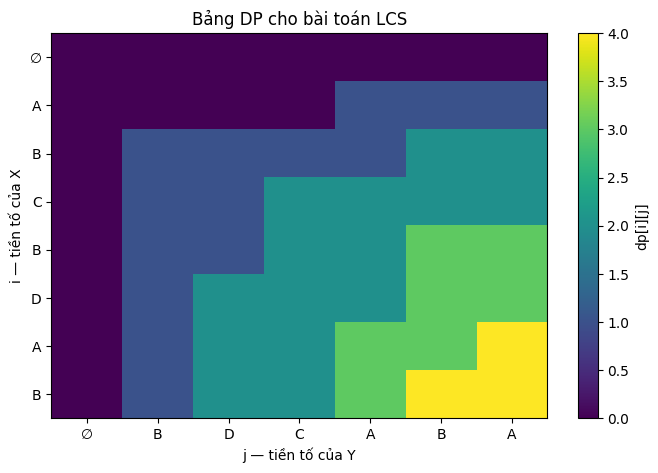

In [21]:
plt.figure(figsize=(8, 5))
plt.imshow(dp_lcs, aspect="auto")
plt.colorbar(label="dp[i][j]")
plt.xlabel("j — tiền tố của Y")
plt.ylabel("i — tiền tố của X")
plt.title("Bảng DP cho bài toán LCS")
plt.xticks(range(len(Y) + 1), ["∅"] + list(Y))
plt.yticks(range(len(X) + 1), ["∅"] + list(X))
plt.show()

## 8. So sánh các bài toán đã học

| Bài toán | Trạng thái | Đáp án | Độ phức tạp |
|---|---|---|---|
| Fibonacci | $$dp[i]$$ | $$dp[n]$$ | $$O(n)$$ |
| Đổi tiền | $$dp[x]$$ | $$dp[n]$$ | $$O(nk)$$ |
| Ba lô 0-1 | $$dp[i][c]$$ | $$dp[n][W]$$ | $$O(nW)$$ |
| LCS | $$dp[i][j]$$ | $$dp[m][n]$$ | $$O(mn)$$ |

Điểm chung:

1. Cần định nghĩa trạng thái rõ ràng.
2. Cần điều kiện cơ sở.
3. Cần công thức truy hồi.
4. Cần thứ tự tính đúng.
5. Có thể truy vết nghiệm nếu lưu thêm thông tin hoặc đi ngược từ bảng DP.

## 9. Những lỗi thường gặp

Khi thiết kế quy hoạch động, sinh viên thường gặp các lỗi sau:

1. **Đặt trạng thái mơ hồ:** không nói rõ $$dp[i]$$ hoặc $$dp[i][j]$$ đại diện cho gì.
2. **Thiếu điều kiện cơ sở:** bảng có ô chưa xác định.
3. **Sai thứ tự tính:** dùng trạng thái chưa được điền.
4. **Nhầm giữa tối đa hóa và tối thiểu hóa.**
5. **Tối ưu bộ nhớ sai chiều:** ba lô 0-1 đi tăng dần theo sức chứa sẽ vô tình cho phép dùng lại vật.
6. **Không truy vết được nghiệm:** chỉ tính giá trị tối ưu nhưng không lưu thông tin để khôi phục phương án.
7. **Không phân tích độ phức tạp:** quên đếm số trạng thái và số lựa chọn mỗi trạng thái.

## 10. Bài tập thực hành

Sinh viên thực hiện các yêu cầu sau.

### Bài 1. Fibonacci

1. Chạy lại phần Fibonacci với $$n=25$$.
2. So sánh số lần gọi trong đệ quy trực tiếp.
3. Giải thích vì sao memoization giảm số lần tính toán.
4. Viết lại hàm Fibonacci tối ưu bộ nhớ mà không dùng mảng.

### Bài 2. Đổi tiền

Với:

$$
D=\{1,4,5\}
$$

hãy lập bảng $$dp[x]$$ cho:

$$
x=0,1,\ldots,8.
$$

Yêu cầu:

1. In bảng $$dp$$.
2. Truy vết tập đồng xu tối ưu cho $$x=8$$.
3. So sánh với chiến lược tham lam.
4. Cho biết tham lam có tối ưu trong trường hợp này không.

### Bài 3. Ba lô 0-1

Cho ba lô có sức chứa:

$$
W=6
$$

và các vật:

$$
(w,v)=\{(2,4),(3,5),(4,7)\}.
$$

Yêu cầu:

1. Tính bảng $$dp$$ hai chiều.
2. In giá trị $$dp[3][6]$$.
3. Truy vết các vật được chọn.
4. Cài đặt bản tối ưu bộ nhớ một chiều và so sánh kết quả.

### Bài 4. LCS

Cho:

$$
X=\text{ABAZDC}
$$

và:

$$
Y=\text{BACBAD}.
$$

Yêu cầu:

1. Tính độ dài một LCS.
2. In bảng $$dp$$.
3. Truy vết một dãy con chung dài nhất.
4. Giải thích ngắn gọn ý nghĩa của ô $$dp[i][j]$$.

### Bài 5. Thiết kế bài toán DP mới

Chọn một bài toán thực tế có thể mô hình hóa bằng quy hoạch động, ví dụ:

- đếm số đường đi trong lưới,
- chọn hoạt động,
- so khớp chuỗi,
- tối ưu chi phí sản xuất,
- phân bổ tài nguyên.

Yêu cầu trình bày:

1. Trạng thái.
2. Điều kiện cơ sở.
3. Công thức truy hồi.
4. Thứ tự tính.
5. Độ phức tạp thời gian và bộ nhớ.

## 10. Lời giải bài tập thực hành

### Bài 1. Fibonacci

In [32]:
# 1. Chạy lại phần Fibonacci với n=25.
n_fib_ex1 = 25
counter_ex1 = {}

# The fib_recursive function is defined in a previous cell (998ad621)
_ = fib_recursive(n_fib_ex1, counter_ex1)

print(f"Fibonacci recursive (n={n_fib_ex1}): {fib_recursive(n_fib_ex1, counter_ex1)}")
print(f"Fibonacci memoization (n={n_fib_ex1}): {fib_memo(n_fib_ex1)}")
print(f"Fibonacci tabulation (n={n_fib_ex1}): {fib_tabulation(n_fib_ex1)}")
print(f"Fibonacci space optimized (n={n_fib_ex1}): {fib_space_optimized(n_fib_ex1)}")

Fibonacci recursive (n=25): 75025
Fibonacci memoization (n=25): 75025
Fibonacci tabulation (n=25): 75025
Fibonacci space optimized (n=25): 75025


#### 2. So sánh số lần gọi trong đệ quy trực tiếp.

,i,Số lần gọi F(i)
0,0,92736
1,1,150050
2,2,92736
3,3,57314
4,4,35422
5,5,21892
6,6,13530
7,7,8362
8,8,5168
9,9,3194


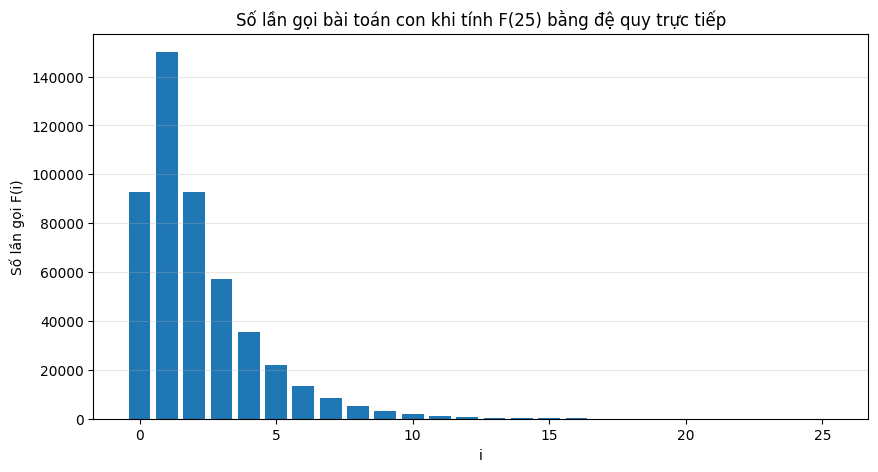

In [33]:
df_calls_ex1 = pd.DataFrame(sorted(counter_ex1.items()), columns=["i", "Số lần gọi F(i)"])
display(df_calls_ex1)

# Visualize the call counts
plt.figure(figsize=(10, 5))
plt.bar(df_calls_ex1["i"], df_calls_ex1["Số lần gọi F(i)"])
plt.xlabel("i")
plt.ylabel("Số lần gọi F(i)")
plt.title(f"Số lần gọi bài toán con khi tính F({n_fib_ex1}) bằng đệ quy trực tiếp")
plt.grid(axis="y", alpha=0.3)
plt.show()

#### 3. Giải thích vì sao memoization giảm số lần tính toán.

Trong đệ quy trực tiếp, các bài toán con (ví dụ, `F(4)` trong ví dụ `F(6) = F(5) + F(4)` và `F(5) = F(4) + F(3)`) thường được tính lại nhiều lần. Điều này dẫn đến sự bùng nổ về số lượng phép tính, đặc biệt với `n` lớn, vì cây đệ quy có nhiều nhánh trùng lặp.

**Memoization** giải quyết vấn đề này bằng cách lưu trữ kết quả của mỗi bài toán con ngay sau khi nó được tính lần đầu. Khi một bài toán con cần được tính lại, thuật toán sẽ kiểm tra bảng lưu trữ (`memo`). Nếu kết quả đã tồn tại, nó sẽ được trả về ngay lập tức thay vì tính toán lại từ đầu. Điều này đảm bảo rằng mỗi bài toán con chỉ được tính toán **một lần duy nhất**, giảm đáng kể số lần gọi hàm và cải thiện hiệu suất từ độ phức tạp thời gian mũ sang tuyến tính (O(n)).

#### 4. Viết lại hàm Fibonacci tối ưu bộ nhớ mà không dùng mảng.

Hàm `fib_space_optimized` đã được cung cấp trong bài lab và nó đã không sử dụng mảng (list) để lưu trữ toàn bộ chuỗi `dp`. Thay vào đó, nó chỉ sử dụng hai biến (`a` và `b`) để lưu trữ hai giá trị Fibonacci gần nhất, giúp giảm bộ nhớ sử dụng xuống `O(1)`.

```python
def fib_space_optimized(n: int) -> int:
    """Fibonacci tối ưu bộ nhớ."""
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b
```

Kiểm tra lại hàm này:


In [34]:
n_test_space_opt = 10
print(f"Fibonacci space optimized (n={n_test_space_opt}): {fib_space_optimized(n_test_space_opt)}")
n_test_space_opt = 25
print(f"Fibonacci space optimized (n={n_test_space_opt}): {fib_space_optimized(n_test_space_opt)}")

Fibonacci space optimized (n=10): 55
Fibonacci space optimized (n=25): 75025


### Bài 2. Đổi tiền

Với các mệnh giá `D={1,4,5}` và số tiền `x=0,1,...,8`.

In [35]:
coins_b2 = [1, 4, 5]
amount_b2 = 8

dp_b2, parent_b2 = min_coins_dp(coins_b2, amount_b2)

# 1. In bảng dp
df_coin_b2 = pd.DataFrame({"x": list(range(amount_b2 + 1)), "dp[x]": dp_b2, "coin cuối": parent_b2})
print("Bảng DP cho bài toán đổi tiền (D={1,4,5}, n=8):")
display(df_coin_b2)

# 2. Truy vết tập đồng xu tối ưu cho x=8.
optimal_coins_b2 = reconstruct_coins(parent_b2, amount_b2)
print(f"\nNghiệm tối ưu cho x={amount_b2}: {optimal_coins_b2}")
print(f"Số đồng tối ưu: {dp_b2[amount_b2]}")

# 3. So sánh với chiến lược tham lam.
greedy_solution_b2 = greedy_coin_change(coins_b2, amount_b2)
print(f"\nChiến lược tham lam chọn: {greedy_solution_b2}")
print(f"Số đồng theo tham lam: {len(greedy_solution_b2)}")

# 4. Cho biết tham lam có tối ưu trong trường hợp này không.
if dp_b2[amount_b2] == len(greedy_solution_b2):
    print("Chiến lược tham lam TỐI ƯU trong trường hợp này.")
else:
    print("Chiến lược tham lam KHÔNG TỐI ƯU trong trường hợp này.")

Bảng DP cho bài toán đổi tiền (D={1,4,5}, n=8):


,x,dp[x],coin cuối
0,0,0,-1
1,1,1,1
2,2,2,1
3,3,3,1
4,4,1,4
5,5,1,5
6,6,2,1
7,7,3,1
8,8,2,4



Nghiệm tối ưu cho x=8: [4, 4]
Số đồng tối ưu: 2

Chiến lược tham lam chọn: [5, 1, 1, 1]
Số đồng theo tham lam: 4
Chiến lược tham lam KHÔNG TỐI ƯU trong trường hợp này.


### Bài 3. Ba lô 0-1

Cho ba lô có sức chứa `W=6` và các vật `(w,v)={(2,4),(3,5),(4,7)}`.

In [36]:
weights_b3 = [2, 3, 4]
values_b3 = [4, 5, 7]
capacity_b3 = 6

# 1. Tính bảng dp hai chiều.
dp_knap_b3, take_knap_b3 = knapsack_01_dp(weights_b3, values_b3, capacity_b3)

print("Bảng DP hai chiều cho bài toán ba lô 0-1:")
display(pd.DataFrame(dp_knap_b3))

# 2. In giá trị dp[3][6].
optimal_value_b3 = dp_knap_b3[len(weights_b3)][capacity_b3]
print(f"\nGiá trị tối ưu (dp[3][6]): {optimal_value_b3}")

# 3. Truy vết các vật được chọn.
selected_items_b3 = reconstruct_knapsack_items(weights_b3, values_b3, capacity_b3, take_knap_b3)
print(f"Các vật được chọn, đánh số từ 1: {selected_items_b3}")

# 4. Cài đặt bản tối ưu bộ nhớ một chiều và so sánh kết quả.
dp_knap_1d_b3 = knapsack_01_optimized(weights_b3, values_b3, capacity_b3)
print(f"\nBảng DP một chiều (tối ưu bộ nhớ): {dp_knap_1d_b3}")
print(f"Giá trị tối ưu từ bản tối ưu bộ nhớ: {dp_knap_1d_b3[capacity_b3]}")

if optimal_value_b3 == dp_knap_1d_b3[capacity_b3]:
    print("Kết quả giữa bản 2 chiều và 1 chiều là KHỚP NHAU.")
else:
    print("Kết quả giữa bản 2 chiều và 1 chiều KHÔNG KHỚP NHAU.")

Bảng DP hai chiều cho bài toán ba lô 0-1:


,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0
1,0,0,4,4,4,4,4
2,0,0,4,5,5,9,9
3,0,0,4,5,7,9,11



Giá trị tối ưu (dp[3][6]): 11
Các vật được chọn, đánh số từ 1: [1, 3]

Bảng DP một chiều (tối ưu bộ nhớ): [0, 0, 4, 5, 7, 9, 11]
Giá trị tối ưu từ bản tối ưu bộ nhớ: 11
Kết quả giữa bản 2 chiều và 1 chiều là KHỚP NHAU.


### Bài 4. LCS

Cho `X="ABAZDC"` và `Y="BACBAD"`.

In [37]:
X_b4 = "ABAZDC"
Y_b4 = "BACBAD"

# Tính bảng DP cho LCS.
dp_lcs_b4 = lcs_dp(X_b4, Y_b4)

# 1. Tính độ dài một LCS.
lcs_length_b4 = dp_lcs_b4[len(X_b4)][len(Y_b4)]
print(f"X = {X_b4}")
print(f"Y = {Y_b4}")
print(f"Độ dài LCS: {lcs_length_b4}")

# 2. In bảng dp.
print("\nBảng DP cho LCS:")
display(pd.DataFrame(dp_lcs_b4, index=[""] + list(X_b4), columns=[""] + list(Y_b4)))

# 3. Truy vết một dãy con chung dài nhất.
lcs_str_b4 = reconstruct_lcs(X_b4, Y_b4, dp_lcs_b4)
print(f"Một LCS: {lcs_str_b4}")

# 4. Giải thích ngắn gọn ý nghĩa của ô dp[i][j].
print("\nÝ nghĩa của ô dp[i][j]:")
print("Ô `dp[i][j]` lưu trữ độ dài của dãy con chung dài nhất (LCS) giữa tiền tố `X[0...i-1]` của xâu X và tiền tố `Y[0...j-1]` của xâu Y. Nói cách khác, đó là độ dài LCS của xâu X gồm `i` ký tự đầu tiên và xâu Y gồm `j` ký tự đầu tiên.")

X = ABAZDC
Y = BACBAD
Độ dài LCS: 4

Bảng DP cho LCS:


,,B,A,C,B,A,D
,0,0,0,0,0,0,0
A,0,0,1,1,1,1,1
B,0,1,1,1,2,2,2
A,0,1,2,2,2,3,3
Z,0,1,2,2,2,3,3
D,0,1,2,2,2,3,4
C,0,1,2,3,3,3,4


Một LCS: ABAD

Ý nghĩa của ô dp[i][j]:
Ô `dp[i][j]` lưu trữ độ dài của dãy con chung dài nhất (LCS) giữa tiền tố `X[0...i-1]` của xâu X và tiền tố `Y[0...j-1]` của xâu Y. Nói cách khác, đó là độ dài LCS của xâu X gồm `i` ký tự đầu tiên và xâu Y gồm `j` ký tự đầu tiên.


### Bài 5. Thiết kế bài toán DP mới: Đếm số đường đi trong lưới (Grid Unique Paths)

**Phát biểu bài toán:**

Cho một lưới `m x n`. Một robot bắt đầu từ ô trên cùng bên trái `(0, 0)` và muốn đi đến ô dưới cùng bên phải `(m-1, n-1)`. Robot chỉ có thể di chuyển xuống dưới hoặc sang phải. Hãy tìm số đường đi duy nhất mà robot có thể đi để đến đích.

Ví dụ: Với lưới `3x7`, có bao nhiêu đường đi?

1.  **Trạng thái:**
    `dp[i][j]` đại diện cho số đường đi duy nhất từ ô `(0,0)` đến ô `(i,j)`.

2.  **Điều kiện cơ sở:**
    *   `dp[0][j] = 1` cho mọi `0 <= j < n` (tức là tất cả các ô trong hàng đầu tiên). Robot chỉ có một cách để đến bất kỳ ô nào trong hàng đầu tiên: chỉ di chuyển sang phải.
    *   `dp[i][0] = 1` cho mọi `0 <= i < m` (tức là tất cả các ô trong cột đầu tiên). Robot chỉ có một cách để đến bất kỳ ô nào trong cột đầu tiên: chỉ di chuyển xuống dưới.

3.  **Công thức truy hồi:**
    Để đến ô `(i,j)`, robot phải đến từ ô `(i-1,j)` (di chuyển xuống) hoặc từ ô `(i,j-1)` (di chuyển sang phải).
    Do đó, số đường đi đến `(i,j)` là tổng số đường đi đến `(i-1,j)` và `(i,j-1)`:
    `dp[i][j] = dp[i-1][j] + dp[i][j-1]`
    Công thức này áp dụng cho `i > 0` và `j > 0`.

4.  **Thứ tự tính:**
    Chúng ta cần tính toán `dp` theo thứ tự tăng dần của `i` và `j`. Điều này có nghĩa là duyệt qua từng hàng, từ trái sang phải, hoặc duyệt qua từng cột, từ trên xuống dưới, để đảm bảo rằng các giá trị `dp[i-1][j]` và `dp[i][j-1]` đã được tính trước khi tính `dp[i][j]`.

5.  **Độ phức tạp thời gian và bộ nhớ:**
    *   **Thời gian:** `O(m * n)` vì chúng ta cần tính toán giá trị cho mỗi ô trong bảng `m x n` và mỗi phép tính mất thời gian hằng số.
    *   **Bộ nhớ:** `O(m * n)` để lưu trữ bảng `dp` hai chiều. Có thể tối ưu bộ nhớ xuống `O(min(m, n))` bằng cách chỉ lưu trữ hàng/cột trước đó, tương tự như tối ưu bộ nhớ trong bài toán ba lô.

In [8]:
def unique_paths(m: int, n: int) -> int:
    """Đếm số đường đi duy nhất trong lưới m x n."""
    dp = [[0] * n for _ in range(m)]

    # Điều kiện cơ sở
    for i in range(m):
        dp[i][0] = 1
    for j in range(n):
        dp[0][j] = 1

    # Công thức truy hồi
    for i in range(1, m):
        for j in range(1, n):
            dp[i][j] = dp[i - 1][j] + dp[i][j - 1]

    return dp[m - 1][n - 1]

m_grid, n_grid = 3, 7
paths = unique_paths(m_grid, n_grid)
print(f"Số đường đi duy nhất trong lưới {m_grid}x{n_grid} là: {paths}")

m_grid, n_grid = 7, 3
paths = unique_paths(m_grid, n_grid)
print(f"Số đường đi duy nhất trong lưới {m_grid}x{n_grid} là: {paths}")

m_grid, n_grid = 3, 3
paths = unique_paths(m_grid, n_grid)
print(f"Số đường đi duy nhất trong lưới {m_grid}x{n_grid} là: {paths}")

Số đường đi duy nhất trong lưới 3x7 là: 28
Số đường đi duy nhất trong lưới 7x3 là: 28
Số đường đi duy nhất trong lưới 3x3 là: 6


In [28]:
# Không gian thực hành cho sinh viên.
# Có thể viết lời giải các bài tập ở các cell bên dưới.

# Bài 2 gợi ý:
coins_ex = [1, 4, 5]
amount_ex = 8

dp_ex, parent_ex = min_coins_dp(coins_ex, amount_ex)
solution_ex = reconstruct_coins(parent_ex, amount_ex)

print("Bài 2 — Đổi tiền")
print("Coins:", coins_ex)
print("Amount:", amount_ex)
print("DP:", dp_ex)
print("Solution:", solution_ex)
print("Number of coins:", dp_ex[amount_ex])

Bài 2 — Đổi tiền
Coins: [1, 4, 5]
Amount: 8
DP: [0, 1, 2, 3, 1, 1, 2, 3, 2]
Solution: [4, 4]
Number of coins: 2


In [29]:
# Bài 3 gợi ý:
weights_ex = [2, 3, 4]
values_ex = [4, 5, 7]
capacity_ex = 6

dp_ex_knap, take_ex_knap = knapsack_01_dp(weights_ex, values_ex, capacity_ex)
selected_ex = reconstruct_knapsack_items(weights_ex, values_ex, capacity_ex, take_ex_knap)

print("Bài 3 — Ba lô 0-1")
print("Optimal value:", dp_ex_knap[len(weights_ex)][capacity_ex])
print("Selected items:", selected_ex)

pd.DataFrame(dp_ex_knap)

Bài 3 — Ba lô 0-1
Optimal value: 11
Selected items: [1, 3]


,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0
1,0,0,4,4,4,4,4
2,0,0,4,5,5,9,9
3,0,0,4,5,7,9,11


In [30]:
# Bài 4 gợi ý:
X_ex = "ABAZDC"
Y_ex = "BACBAD"

dp_ex_lcs = lcs_dp(X_ex, Y_ex)
lcs_ex = reconstruct_lcs(X_ex, Y_ex, dp_ex_lcs)

print("Bài 4 — LCS")
print("X =", X_ex)
print("Y =", Y_ex)
print("LCS length:", dp_ex_lcs[len(X_ex)][len(Y_ex)])
print("One LCS:", lcs_ex)

pd.DataFrame(dp_ex_lcs, index=[""] + list(X_ex), columns=[""] + list(Y_ex))

Bài 4 — LCS
X = ABAZDC
Y = BACBAD
LCS length: 4
One LCS: ABAD


,,B,A,C,B,A,D
,0,0,0,0,0,0,0
A,0,0,1,1,1,1,1
B,0,1,1,1,2,2,2
A,0,1,2,2,2,3,3
Z,0,1,2,2,2,3,3
D,0,1,2,2,2,3,4
C,0,1,2,3,3,3,4


## 11. Câu hỏi thảo luận

### 1. Khi nào nên dùng memoization thay vì tabulation?

Nên dùng **memoization** khi bài toán có nhiều trạng thái nhưng trong thực tế **không cần tính hết tất cả trạng thái**.

Memoization là cách làm **top-down**:

- Gọi đệ quy từ bài toán lớn.
- Cần trạng thái nào thì tính trạng thái đó.
- Sau khi tính xong thì lưu lại để lần sau dùng tiếp.

Nên dùng memoization khi:

- Công thức truy hồi dễ viết theo đệ quy.
- Không biết rõ thứ tự tính bảng.
- Số trạng thái có thể rất nhiều nhưng chỉ một phần được sử dụng.
- Bài toán có dạng thử chọn / không chọn.

Ví dụ:

- Fibonacci có nhớ.
- Ba lô 0-1 dạng đệ quy.
- Các bài toán tìm kiếm trạng thái có lưu kết quả.

---

### 2. Khi nào tabulation thuận lợi hơn memoization?

Nên dùng **tabulation** khi ta biết rõ thứ tự tính từ bài toán nhỏ đến bài toán lớn.

Tabulation là cách làm **bottom-up**:

- Tạo bảng trước.
- Điền các trạng thái cơ sở.
- Tính dần lên các trạng thái lớn hơn.

Tabulation thuận lợi hơn khi:

- Hầu hết trạng thái đều cần tính.
- Biết rõ thứ tự duyệt bảng.
- Muốn tránh lỗi tràn stack do đệ quy sâu.
- Muốn tối ưu bộ nhớ dễ hơn.
- Muốn chương trình chạy ổn định và nhanh hơn.

Ví dụ:

- LCS.
- Knapsack.
- Coin Change.
- Fibonacci dạng vòng lặp.

---

### 3. Vì sao ba lô 0-1 khi tối ưu bộ nhớ phải duyệt sức chứa theo chiều giảm?

Trong bài toán **ba lô 0-1**, mỗi vật chỉ được chọn **tối đa một lần**.

Công thức gốc là:

```text
dp[i][w] = max(dp[i-1][w], dp[i-1][w - weight[i]] + value[i])

## 12. Yêu cầu nộp bài

Sinh viên nộp một file notebook `.ipynb` đã chạy đầy đủ kết quả.

File nộp cần có:

1. Thông tin sinh viên ở đầu notebook.
2. Kết quả chạy các phần Fibonacci, đổi tiền, ba lô 0-1 và LCS.
3. Ít nhất 3 hình hoặc bảng trực quan hóa kết quả.
4. Lời giải các bài tập trong Mục 10.
5. Câu trả lời cho các câu hỏi thảo luận trong Mục 11.

Tên file nộp theo định dạng:

```text
HoTen_MaSinhVien_Lab_Dynamic_Programming.ipynb
```